# Filtros espaciales
OpenCV dispone de un conjunto de filtros espaciales ya implementados.
Además, dispone de la función genérica `filter2D` que permite aplicar cualquier filtro espacial a una imagen.

## Media

El filtro de medias se puede aplicar con la función `blur`. Esta función recibe como parámetros la imagen de entrada y el tamaño de filtro a aplicar (positivo e impar).



/content
/content


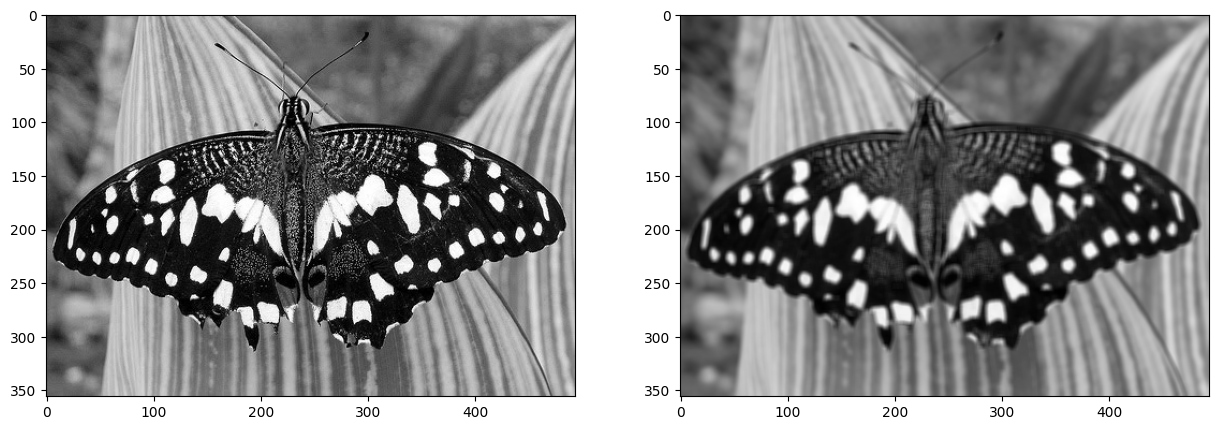

In [6]:
%matplotlib inline
import cv2
import numpy as np
from matplotlib import pyplot as plt
!pwd
%cd /content
plt.rcParams["figure.figsize"] = [15,10]


im = cv2.imread('/content/drive/MyDrive/res/butterfly.jpg', cv2.IMREAD_GRAYSCALE)
blur = cv2.blur(im,(5,5)) # Filtro de medias de tamaño 5x5

f, ax = plt.subplots(1,2)
ax[0].imshow(im, cmap='gray')
ax[1].imshow(blur, cmap='gray')
plt.show()




### Ejercicio
Aplica a la imagen `butterfly.jpg` filtros de medias de tamaño 3x3 y 9x9. Qué diferencias se aprecian?

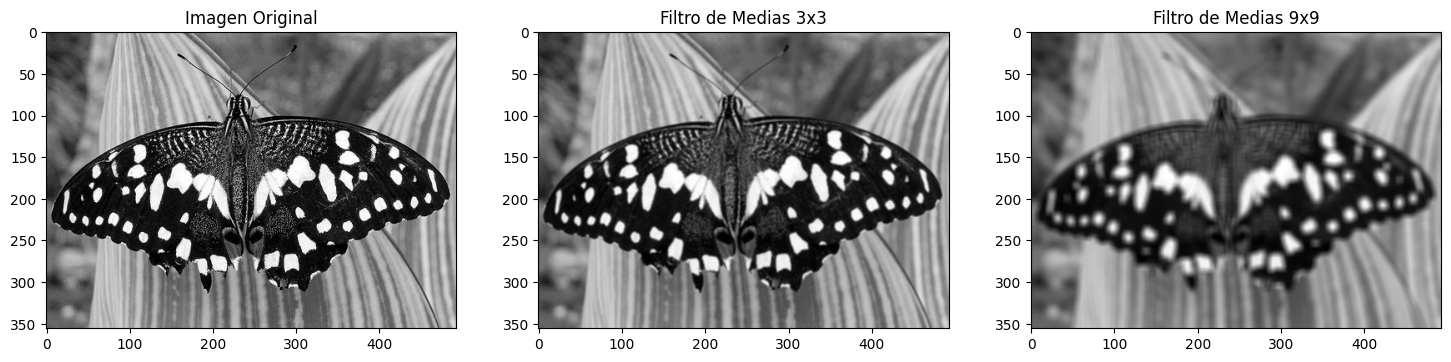

In [8]:
# Aplicar filtros de medias de 3x3 y 9x9
blur3x3 = cv2.blur(im, (3,3))
blur9x9 = cv2.blur(im, (9,9))

# Mostrar los resultados
f, ax = plt.subplots(1, 3, figsize=(18, 6))
ax[0].imshow(im, cmap='gray')
ax[0].set_title('Imagen Original')
ax[1].imshow(blur3x3, cmap='gray')
ax[1].set_title('Filtro de Medias 3x3')
ax[2].imshow(blur9x9, cmap='gray')
ax[2].set_title('Filtro de Medias 9x9')
plt.show()

## Gaussiana
La función `GaussianBlur` aplica un suavizado gaussiano a la imagen. Esta función recibe tres o cuatro parámetros:
- La imagen de entrada.
- El tamaño del filtro (positivo e impar)
- Desviación típica en la dirección X
- Desviación típica en la dirección Y.

Si sólo se indica un valor de desviación típica, este valor se aplica tanto a X como a Y. Si, además, este valor es 0, la desviación típica se calculará automáticamente a partir del tamaño del kernel.

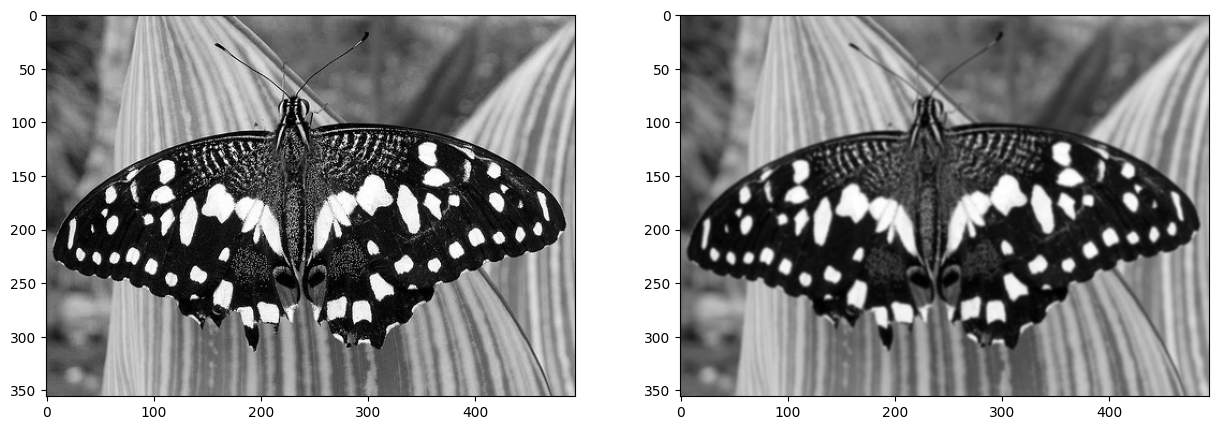

In [9]:
gaus = cv2.GaussianBlur(im, (5,5), 0)
f, ax = plt.subplots(1,2)
ax[0].imshow(im, cmap='gray')
ax[1].imshow(gaus, cmap='gray')
plt.show()

### Ejercicio
Compara la salida de aplicar a la imagen `butterfly.jpg`un filtro de medias de 11x11 y un filtro gaussiando del mismo tamaño (usar 0 como parámetro de desviación típica). Cuál de los dos filtros ofrece un mejor resultado?

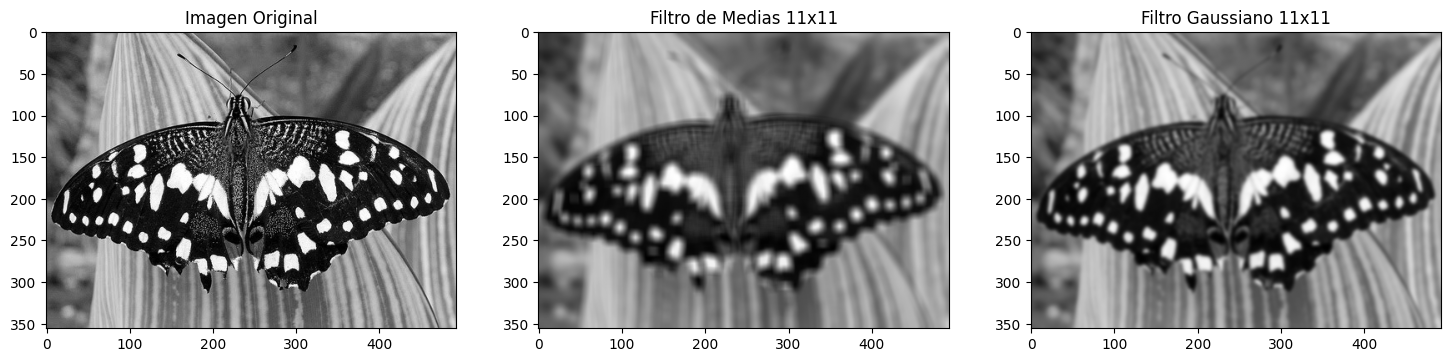

In [10]:
# Aplicar filtros de 11x11
blur11x11 = cv2.blur(im, (11,11))
gaus11x11 = cv2.GaussianBlur(im, (11,11), 0)

# Mostrar los resultados
f, ax = plt.subplots(1, 3, figsize=(18, 6))
ax[0].imshow(im, cmap='gray')
ax[0].set_title('Imagen Original')
ax[1].imshow(blur11x11, cmap='gray')
ax[1].set_title('Filtro de Medias 11x11')
ax[2].imshow(gaus11x11, cmap='gray')
ax[2].set_title('Filtro Gaussiano 11x11')
plt.show()

## Mediana

La función `medianBlur` permite aplicar el filtro de mediana a una imagen. Toma dos parámetros, la imagen de entrada y el tamaño del filtro.

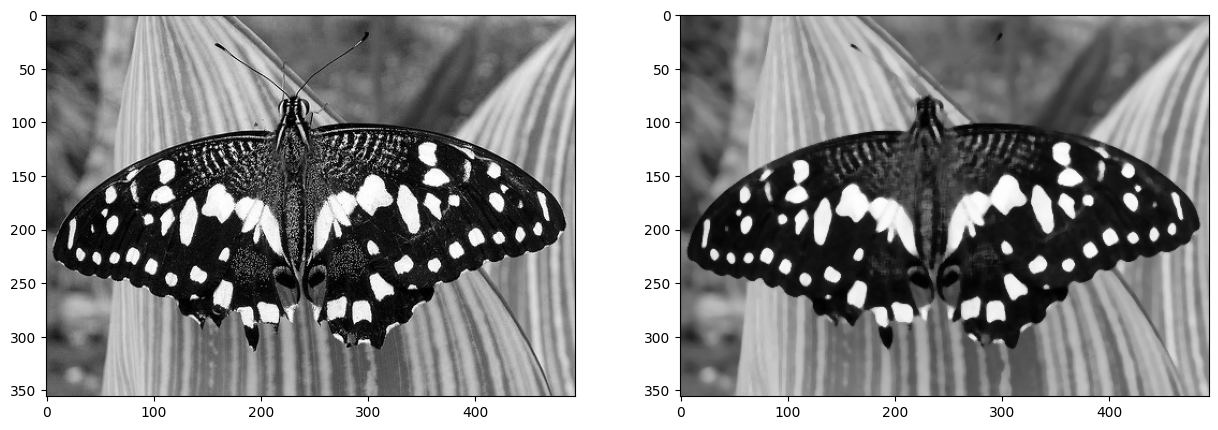

In [11]:
median = cv2.medianBlur(im, 5)
f, ax = plt.subplots(1,2)
ax[0].imshow(im, cmap='gray')
ax[1].imshow(median, cmap='gray')
plt.show()

# Operadores morfológicos

Los operadores morfológicos operan en la forma de la imagen. Normalmente se aplican sobre imágenes binarias (blanco/negro) y necesitan dos entradas, la imagen original y lo que se denomina elemento estructurante. Dicho elemento estructurante es un kernel que determina la naturaleza de la operación a realizar.


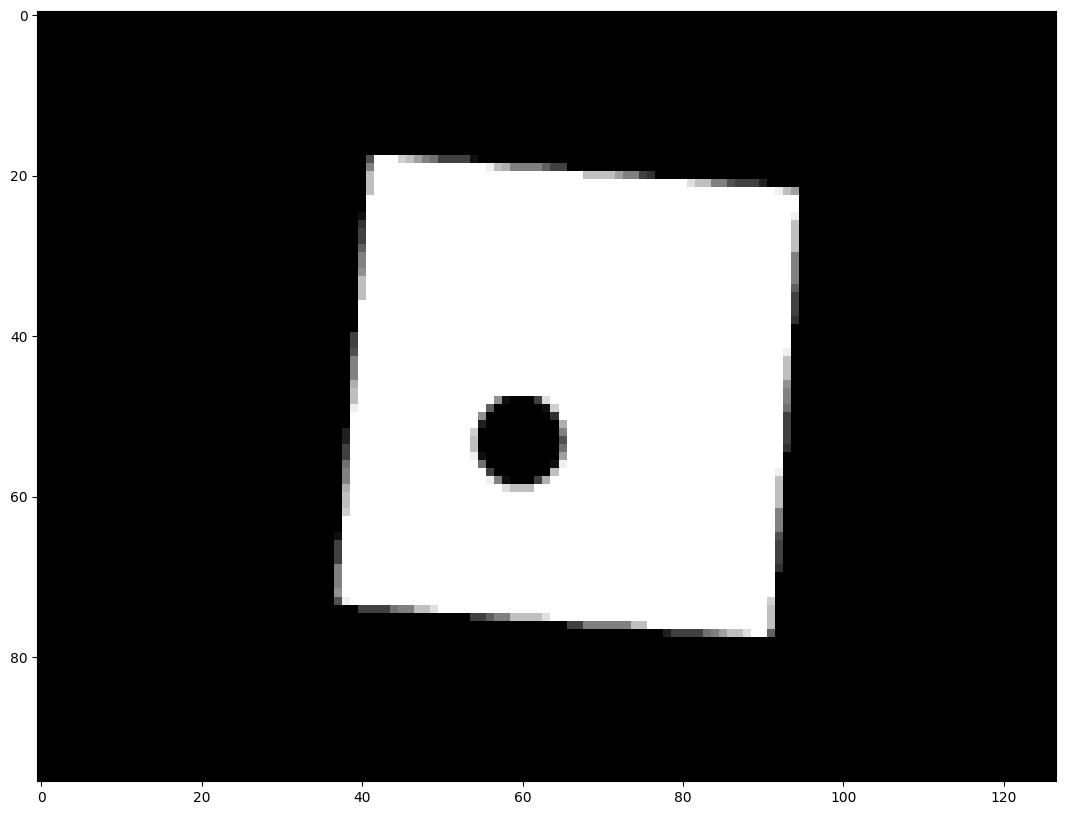

In [13]:
im = cv2.imread('/content/drive/MyDrive/res/morph1.png', cv2.IMREAD_GRAYSCALE)
plt.imshow(im,cmap='gray')
plt.show()

## Elemento estructurante
Un elemento estructurante es un kernel formado por 1 y 0 que determina la forma con la que se aplicará el operador morfológico. Podemos crear los elementos estructurantes a través de matrices numpy o bien utilizar una función propia de OpenCV

In [14]:
kernel = np.ones((5,5), np.uint8)
print(kernel)

# Circular
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))
print (kernel)

# Cruz
kernel = cv2.getStructuringElement(cv2.MORPH_CROSS, (5,5))
print (kernel)

[[1 1 1 1 1]
 [1 1 1 1 1]
 [1 1 1 1 1]
 [1 1 1 1 1]
 [1 1 1 1 1]]
[[0 0 1 0 0]
 [1 1 1 1 1]
 [1 1 1 1 1]
 [1 1 1 1 1]
 [0 0 1 0 0]]
[[0 0 1 0 0]
 [0 0 1 0 0]
 [1 1 1 1 1]
 [0 0 1 0 0]
 [0 0 1 0 0]]


## Erosión y dilatación
La erosión es una de las operaciones morfológicas básicas. Como su propio nombre indica, su efecto es "erosionar" las paredes de los objetos de primer plano (blanco). En la imagen resultado un pixel tomará valor 1 sólo si todos los píxeles bajo el elemento estructurante tienen también valor 1.

La dilatación es el proceso inverso a la erosión. Si al menos un pixel de la imagen original tiene valor 1 bajo el elemento estructurante, el pixel tomará valor 1 en la imagen resultante. Por tanto, esta operación sirve para rellenar huecos en el objeto de primer plano (blanco).

Las funciones `erode` y `dilate` toman tres parámetros:
- La imagen original binaria
- El elemento estructurante
- En número de iteraciones que se aplicará la operación

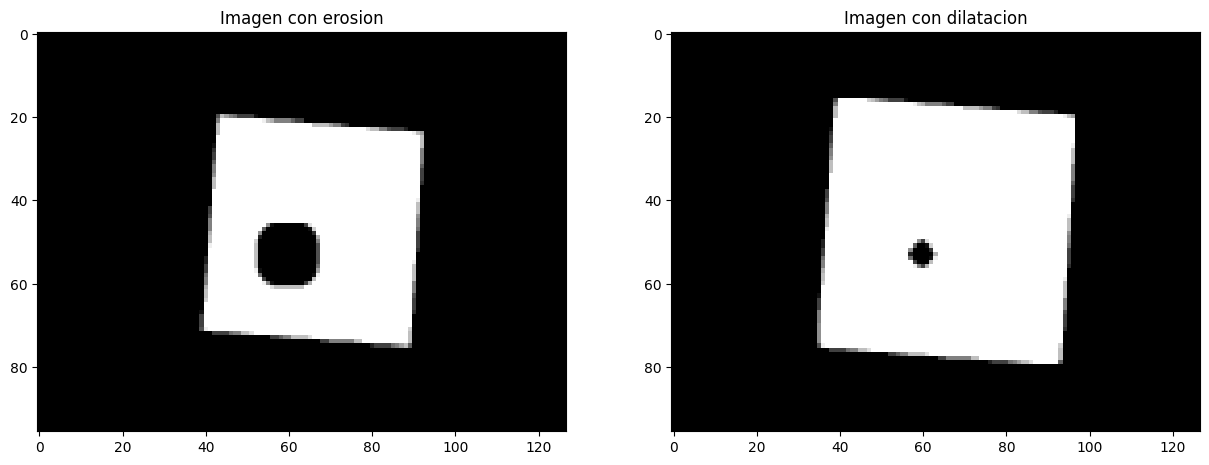

In [15]:
kernel = np.ones((5,5), np.uint8)
erosion = cv2.erode(im, kernel, iterations=1)


kernel = np.ones((5,5), np.uint8)
dilation = cv2.dilate(im, kernel, iterations=1)

f, ax = plt.subplots(1,2)
ax[0].set_title('Imagen con erosion')
ax[0].imshow(erosion,cmap='gray')
ax[1].set_title('Imagen con dilatacion')
ax[1].imshow(dilation,cmap='gray')
plt.show()


### Ejercicios

1) Erosiona la imagen `res/morph1.png` durante 10 iteraciones. Qué ocurre?

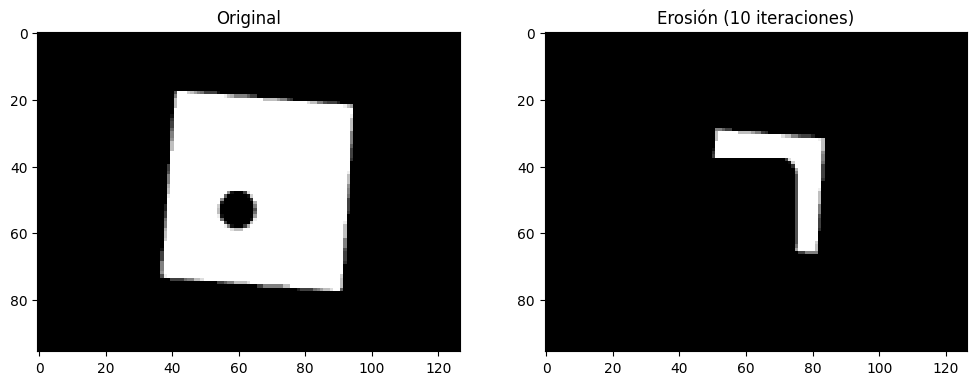

In [24]:
# Definir kernel y aplicar erosión por 10 iteraciones
kernel = np.ones((3,3), np.uint8)
erosion10 = cv2.erode(im, kernel, iterations=10)

# Mostrar resultados
f, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(im, cmap='gray')
ax[0].set_title('Original')
ax[1].imshow(erosion10, cmap='gray')
ax[1].set_title('Erosión (10 iteraciones)')
plt.show()

2) Rellena el hueco circular la imagen `res/morph1.png` utilizando dilataciones. Qué ocurre con los bordes externos del cuadrado?


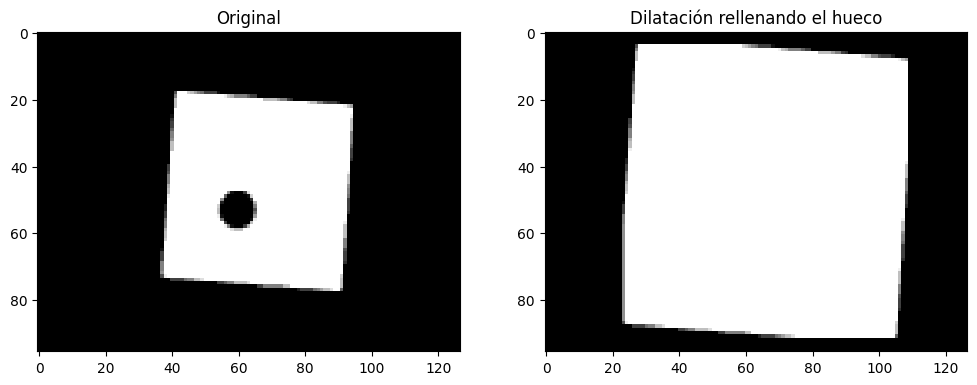

In [17]:
kernel = np.ones((5,5), np.uint8)
# Aumentamos las iteraciones para conseguir cerrar el agujero (ej. 7 iteraciones)
dilation_hueco = cv2.dilate(im, kernel, iterations=7)

f, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(im, cmap='gray')
ax[0].set_title('Original')
ax[1].imshow(dilation_hueco, cmap='gray')
ax[1].set_title('Dilatación rellenando el hueco')
plt.show()

## Otros operadores

La función `morphologyEx` se utiliza para aplicar otros operadores morfológicos derivados de erosiones y dilataciones. Esta función toma los siguientes parámetros:

- Imagen original binaria
- El tipo de operación a realizar (`cv2.MORPH_OPEN`, `cv2.MORPH_CLOSE`, `cv2.MORPH_TOPHAT`, `cv2.MORPH_BLACKHAT`, `cv2.MORPH_GRADIENT`)
- El elemento estructurante

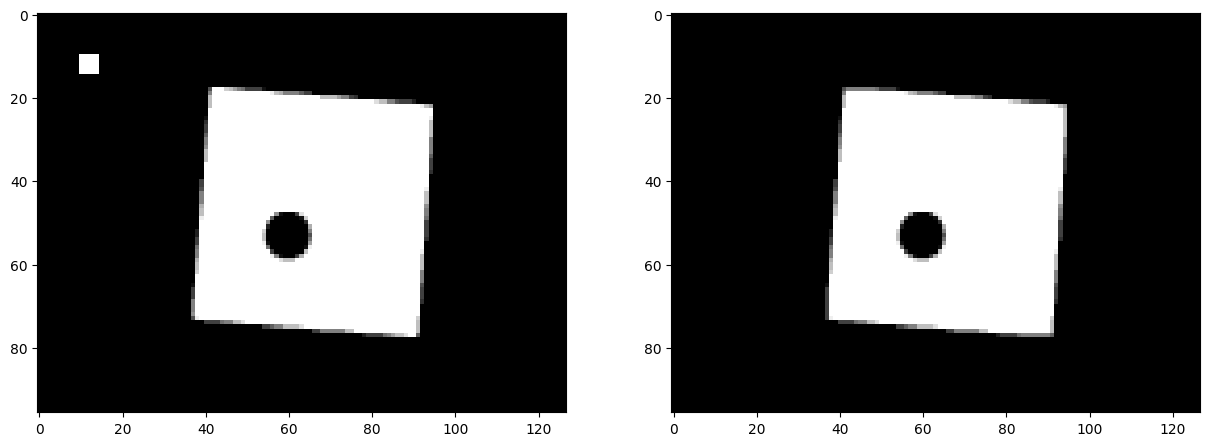

In [18]:
im2 = im * 1
im2[10:15, 10:15] = 255 # Creamos un cuadrado en la imagen

kernel = np.ones((7,7), np.uint8)
opening = cv2.morphologyEx(im2, cv2.MORPH_OPEN, kernel)
fig, ax = plt.subplots(1,2)
ax[0].imshow(im2,cmap='gray')
ax[1].imshow(opening,cmap='gray')
plt.show()

### Ejercicio

Rellena el hueco de la imagen `res/morph1.png` sin alterar el tamaño del objeto.

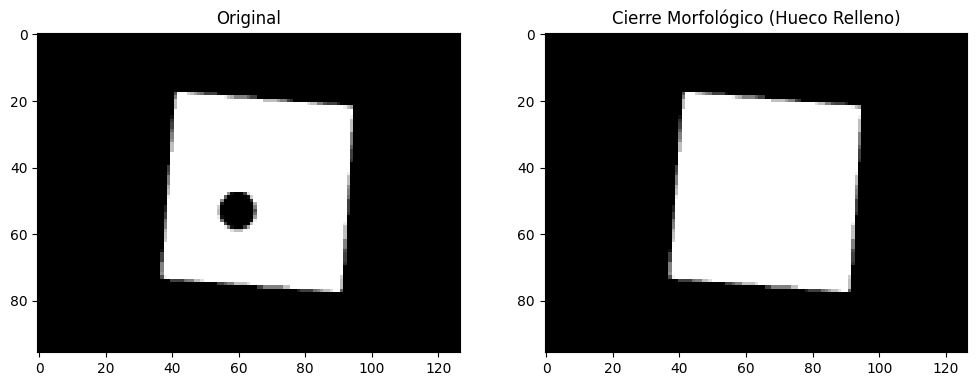

In [25]:
# Necesitamos un kernel suficientemente grande para cubrir el diámetro del hueco de una vez
kernel_close = np.ones((35,35), np.uint8)

# Aplicar la operación de Cierre (Cerrar agujeros oscuros)
closing = cv2.morphologyEx(im, cv2.MORPH_CLOSE, kernel_close)

f, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(im, cmap='gray')
ax[0].set_title('Original')
ax[1].imshow(closing, cmap='gray')
ax[1].set_title('Cierre Morfológico (Hueco Relleno)')
plt.show()

### Ejercicio

Consigue el contorno de la imagen `res/pikachu.jfif` utilizando operadores/algoritmos morfológicos.

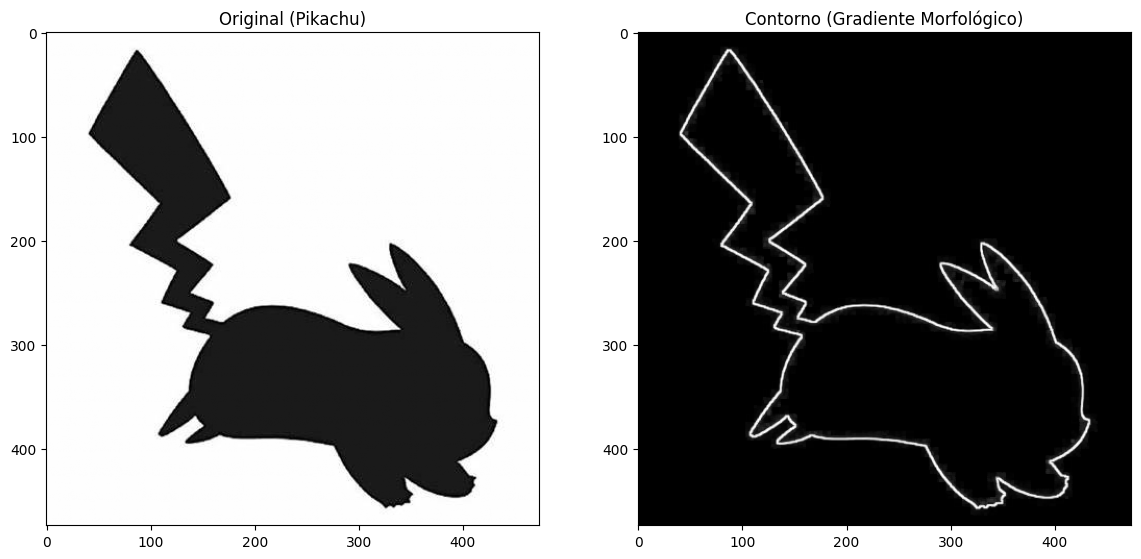

In [26]:
# Cargar la imagen de Pikachu
im_pika = cv2.imread('/content/drive/MyDrive/res/pikachu.jfif', cv2.IMREAD_GRAYSCALE)

# Definir un kernel pequeño para que la línea de contorno sea fina
kernel_grad = np.ones((3,3), np.uint8)

# Calcular el gradiente morfológico
contorno = cv2.morphologyEx(im_pika, cv2.MORPH_GRADIENT, kernel_grad)

# Invertir el color (opcional, para verlo mejor si el fondo es blanco)
# contorno = cv2.bitwise_not(contorno)

f, ax = plt.subplots(1, 2, figsize=(14, 7))
ax[0].imshow(im_pika, cmap='gray')
ax[0].set_title('Original (Pikachu)')
ax[1].imshow(contorno, cmap='gray')
ax[1].set_title('Contorno (Gradiente Morfológico)')
plt.show()